# Feature Engineering + Threshold Tuning — Francisco Hernandez

Adds to the team's work: 36 engineered features, stratified 5-fold CV in place of the
single validation split, and decision thresholds tuned on out-of-fold predictions.

Two results:
1. Feature engineering and algorithm strength are substitutes — engineered features help
   logistic regression far more than they help gradient boosting.
2. The earlier "Decision Tree wins F1 but Gradient Boosting wins AUC" contradiction was a
   thresholding artifact, and reverses once cutoffs are tuned.

Runtime is about 4 minutes (2 feature sets x 6 models x 5 folds = 60 fits).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (average_precision_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score)

warnings.filterwarnings("ignore")
SEED = 42
BLUE, ORANGE = "#2a78d6", "#eb6834"   # colorblind-safe pair

## 1. Load and clean

In [2]:
URL = "https://raw.githubusercontent.com/cameronmoran23/ADS504-Group6-FinalProject/main/data.csv"
try:
    raw = pd.read_csv(URL)
except Exception:
    raw = pd.read_csv("data.csv")

RENAME = {"ID": "id", "LIMIT_BAL": "limit_bal", "SEX": "sex", "EDUCATION": "education",
          "MARRIAGE": "marriage", "AGE": "age", "PAY_0": "pay_1",
          "default payment next month": "default"}
RENAME |= {f"PAY_{i}": f"pay_{i}" for i in range(2, 7)}
RENAME |= {f"BILL_AMT{i}": f"bill_amt{i}" for i in range(1, 7)}
RENAME |= {f"PAY_AMT{i}": f"pay_amt{i}" for i in range(1, 7)}
df = raw.rename(columns=RENAME)

PAY_COLS  = [f"pay_{i}" for i in range(1, 7)]
BILL_COLS = [f"bill_amt{i}" for i in range(1, 7)]
AMT_COLS  = [f"pay_amt{i}" for i in range(1, 7)]

# No NaNs, but 399 records carry codes absent from the UCI codebook:
# education has 0/5/6 (documented 1-4), marriage has 0 (documented 1-3).
# Fold them into the documented "other" bucket.
df["education"] = df["education"].replace({0: 4, 5: 4, 6: 4})
df["marriage"] = df["marriage"].replace({0: 3})
df["default"] = df["default"].astype(int)

print(df.shape, "| default rate:", round(df["default"].mean(), 3))

(30000, 25) | default rate: 0.221


## 2. Feature engineering

Five families. The `pay_*` columns get split apart because they overload two things:
1-9 are months late (ordinal), but -2/-1/0 are states (no usage, paid duly, revolving).
Feeding them in as one numeric column asserts a scale that doesn't exist.

In [3]:
def safe_ratio(num, den, clip=None):
    """num/den where den can be zero or negative (overpayment credit)."""
    num, den = np.asarray(num, float), np.asarray(den, float)
    out = np.divide(num, den, out=np.zeros_like(num), where=den > 0)
    return np.clip(out, *clip) if clip else out


def engineer(data):
    X = data.copy()
    limit = X["limit_bal"].astype(float)

    # 1. Credit utilization — balance relative to the client's own limit
    for i in range(1, 7):
        X[f"util{i}"] = safe_ratio(X[f"bill_amt{i}"], limit, clip=(-1, 5))
    util = X[[f"util{i}" for i in range(1, 7)]]
    X["util_mean"], X["util_max"] = util.mean(axis=1), util.max(axis=1)
    X["util_std"] = util.std(axis=1)
    X["util_trend"] = X["util1"] - X["util6"]

    # 2. Payment ratio — pay_amt(t) settles the month t+1 statement, not month t
    for i in range(1, 6):
        X[f"pay_ratio{i}"] = safe_ratio(X[f"pay_amt{i}"], X[f"bill_amt{i+1}"], clip=(0, 2))
    pr = X[[f"pay_ratio{i}" for i in range(1, 6)]]
    X["pay_ratio_mean"], X["pay_ratio_min"] = pr.mean(axis=1), pr.min(axis=1)
    X["pay_ratio_trend"] = X["pay_ratio1"] - X["pay_ratio5"]

    # 3. Delinquency, separated from the overloaded status codes
    pay = X[PAY_COLS]
    late = pay.clip(lower=0)
    X["delinq_months"] = (pay >= 1).sum(axis=1)
    X["delinq_max"], X["delinq_mean"] = late.max(axis=1), late.mean(axis=1)
    X["delinq_current"] = late["pay_1"]
    X["ever_delinq"] = (X["delinq_months"] > 0).astype(int)
    # Consecutive late months ending at the most recent statement
    flags, streak = (pay >= 1).to_numpy(), np.zeros(len(X), int)
    running = np.ones(len(X), bool)
    for j in range(6):                       # pay_1 -> pay_6 = recent -> oldest
        running &= flags[:, j]
        streak += running
    X["delinq_streak"] = streak
    X["n_revolving"] = (pay == 0).sum(axis=1)
    X["n_paid_duly"] = (pay == -1).sum(axis=1)
    X["n_no_usage"] = (pay == -2).sum(axis=1)

    # 4. Payment behavior
    X["n_zero_payments"] = (X[AMT_COLS] == 0).sum(axis=1)
    X["total_paid"] = X[AMT_COLS].sum(axis=1)
    X["paid_to_billed"] = safe_ratio(X["total_paid"], X[BILL_COLS].clip(lower=0).sum(axis=1),
                                     clip=(0, 2))
    X["pay_amt_mean"], X["pay_amt_std"] = X[AMT_COLS].mean(axis=1), X[AMT_COLS].std(axis=1)

    # 5. Balance trajectory
    X["bill_trend"] = X["bill_amt1"] - X["bill_amt6"]
    X["bill_mean"], X["bill_std"] = X[BILL_COLS].mean(axis=1), X[BILL_COLS].std(axis=1)
    X["remaining_credit"] = limit - X["bill_amt1"]
    return X


fe = engineer(df)
engineered = [c for c in fe.columns if c not in df.columns]
print(f"{len(engineered)} engineered features | NaN: {fe[engineered].isna().sum().sum()}")

36 engineered features | NaN: 0


## 3. Validation setup

20% test set held out once and untouched until section 6. Everything else uses stratified
5-fold CV on the remaining 80%. Thresholds are tuned on out-of-fold predictions, so no
model picks its own cutoff on data it trained on.

In [4]:
CATEGORICAL = ["sex", "education", "marriage"]
raw_features = [c for c in df.columns if c not in ("id", "default")]
eng_features = [c for c in fe.columns if c not in ("id", "default")]
y = fe["default"]
idx_train, idx_test = train_test_split(fe.index, test_size=0.20, random_state=SEED, stratify=y)


def make_preprocessor(cols):
    cats = [c for c in CATEGORICAL if c in cols]
    return ColumnTransformer([
        ("num", StandardScaler(), [c for c in cols if c not in cats]),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cats)])


# NOTE: class_weight="balanced" applies to LogisticRegression, DecisionTree and
# RandomForest only — sklearn provides no such parameter for GradientBoosting or MLP.
# That asymmetry is what made the original F1-at-0.5 comparison misleading.
MODELS = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced",
                                              random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced",
                                            random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100,
                                          early_stopping=True, random_state=SEED),
}


def best_threshold(y_true, proba):
    grid = np.unique(np.round(np.quantile(proba, np.linspace(.01, .99, 199)), 4))
    scores = [f1_score(y_true, (proba >= t).astype(int), zero_division=0) for t in grid]
    i = int(np.argmax(scores))
    return float(grid[i]), float(scores[i])


def cv_evaluate(X, y, n_splits=5):
    """Returns one row per model: fold-mean metrics plus the OOF-tuned threshold."""
    folds = list(StratifiedKFold(n_splits, shuffle=True, random_state=SEED).split(X, y))
    rows = []
    for name, model in MODELS.items():
        oof, fold_metrics = np.zeros(len(y)), []
        for tr, va in folds:
            pipe = Pipeline([("prep", make_preprocessor(list(X.columns))),
                             ("model", clone(model))])
            pipe.fit(X.iloc[tr], y.iloc[tr])
            p = pipe.predict_proba(X.iloc[va])[:, 1]
            oof[va] = p
            fold_metrics.append((
                average_precision_score(y.iloc[va], p),
                roc_auc_score(y.iloc[va], p) if len(np.unique(p)) > 1 else 0.5,
                f1_score(y.iloc[va], (p >= .5).astype(int), zero_division=0)))
        m = np.array(fold_metrics).mean(axis=0)
        thr, f1_tuned = best_threshold(y, oof)
        rows.append({"Model": name, "PR-AUC": m[0], "ROC-AUC": m[1],
                     "F1 @ 0.5": m[2], "F1 @ tuned": f1_tuned, "Threshold": thr})
    return pd.DataFrame(rows).set_index("Model")

## 4. Run: raw vs engineered features

In [5]:
results = {}
for label, cols in (("Raw", raw_features), ("Engineered", eng_features)):
    print(f"running {label} ...", flush=True)
    results[label] = cv_evaluate(fe.loc[idx_train, cols], y.loc[idx_train])

comparison = pd.concat(results, names=["Feature Set"]).round(4)
comparison

running Raw ...


running Engineered ...


PR-AUC  ROC-AUC  F1 @ 0.5  F1 @ tuned  \
Feature Set Model                                                         
Raw         Dummy                 0.2212   0.5000    0.0000      0.3623   
            Logistic Regression   0.5045   0.7275    0.4811      0.5149   
            Decision Tree         0.5089   0.7570    0.5314      0.5303   
            Random Forest         0.5364   0.7715    0.5300      0.5334   
            Gradient Boosting     0.5538   0.7813    0.4790      0.5444   
            Neural Network (MLP)  0.5326   0.7676    0.4557      0.5381   
Engineered  Dummy                 0.2212   0.5000    0.0000      0.3623   
            Logistic Regression   0.5351   0.7766    0.5286      0.5402   
            Decision Tree         0.5180   0.7680    0.5233      0.5361   
            Random Forest         0.5376   0.7717    0.5254      0.5308   
            Gradient Boosting     0.5614   0.7878    0.4775      0.5469   
            Neural Network (MLP)  0.5460   0.7790    0.4798      0.5403   

                                  Threshold  
Feature Set Model                            
Raw         Dummy                    0.0000  
            Logistic Regression      0.5835  
            Decision Tree            0.5349  
            Random Forest            0.4705  
            Gradient Boosting        0.2439  
            Neural Network (MLP)     0.2648  
Engineered  Dummy                    0.0000  
            Logistic Regression      0.5873  
            Decision Tree            0.5502  
            Random Forest            0.4367  
            Gradient Boosting        0.2442  
            Neural Network (MLP)     0.3109

## 5. Results

**Feature engineering vs algorithm strength.** PR-AUC is threshold-free, so it measures
how well a model ranks risk rather than how it behaves at one cutoff. The gain from
engineered features shrinks as the model gets stronger: the engineered ratios hand a
linear model structure the ensembles were already finding through splits.

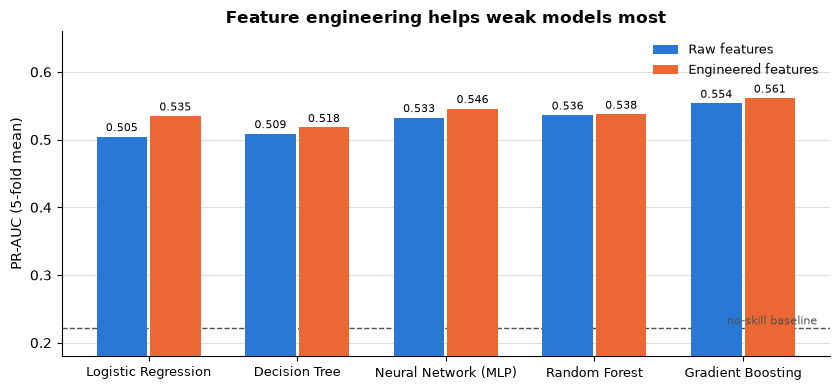

,Raw,Engineered,Gain %
Model,,,
Logistic Regression,0.5045,0.5351,6.1
Decision Tree,0.5089,0.5180,1.8
Neural Network (MLP),0.5326,0.5460,2.5
Random Forest,0.5364,0.5376,0.2
Gradient Boosting,0.5538,0.5614,1.4


In [6]:
ablation = pd.DataFrame({"Raw": results["Raw"]["PR-AUC"],
                         "Engineered": results["Engineered"]["PR-AUC"]}).drop("Dummy")
ablation["Gain %"] = ((ablation["Engineered"] / ablation["Raw"] - 1) * 100).round(1)
ablation = ablation.sort_values("Raw")

fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(len(ablation))
for off, col, c in ((-.18, "Raw", BLUE), (.18, "Engineered", ORANGE)):
    b = ax.bar(x + off, ablation[col], .34, label=f"{col} features", color=c, zorder=3)
    ax.bar_label(b, fmt="%.3f", fontsize=8, padding=2)
ax.axhline(y.mean(), ls="--", c="#52514e", lw=1)
ax.text(len(ablation) - .5, y.mean() + .006, "no-skill baseline", ha="right", fontsize=8,
        color="#52514e")
ax.set_xticks(x, ablation.index, fontsize=9)
ax.set_ylabel("PR-AUC (5-fold mean)"); ax.set_ylim(.18, .66)   # headroom so the legend clears the bar labels
ax.set_title("Feature engineering helps weak models most", fontweight="bold")
ax.legend(fontsize=9, frameon=False); ax.set_axisbelow(True); ax.grid(axis="y", alpha=.4)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

ablation.round(4)

**The threshold confound.** Every model was originally scored at a fixed 0.5 cutoff on a
22.1% positive target. Balanced class weighting shifts minority-class probabilities up, so
weighted models clear 0.5 more often and gain F1 for it — but Gradient Boosting and the MLP
never got that adjustment, because sklearn doesn't offer it for them. Tune each cutoff
consistently and the ranking reverses to match PR-AUC.

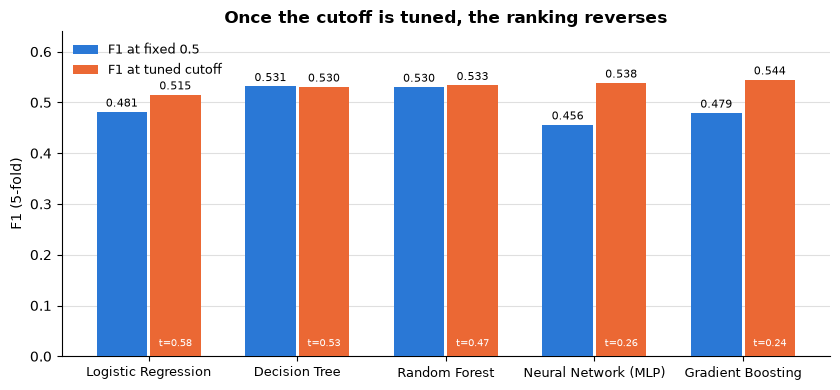

Balanced models land near 0.5 because weighting already moved their probabilities.
Gradient Boosting needs ~0.24 because nothing moved its probabilities at all.


In [7]:
comp = results["Raw"].drop("Dummy")[["F1 @ 0.5", "F1 @ tuned", "Threshold"]].sort_values("F1 @ tuned")

fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(len(comp))
b1 = ax.bar(x - .18, comp["F1 @ 0.5"], .34, label="F1 at fixed 0.5", color=BLUE, zorder=3)
b2 = ax.bar(x + .18, comp["F1 @ tuned"], .34, label="F1 at tuned cutoff", color=ORANGE, zorder=3)
ax.bar_label(b1, fmt="%.3f", fontsize=8, padding=2)
ax.bar_label(b2, fmt="%.3f", fontsize=8, padding=2)
for i, t in enumerate(comp["Threshold"]):
    ax.text(i + .18, .02, f"t={t:.2f}", ha="center", fontsize=7.5, color="white")
ax.set_xticks(x, comp.index, fontsize=9)
ax.set_ylabel("F1 (5-fold)"); ax.set_ylim(0, .64)
ax.set_title("Once the cutoff is tuned, the ranking reverses", fontweight="bold")
ax.legend(fontsize=9, frameon=False, loc="upper left")
ax.set_axisbelow(True); ax.grid(axis="y", alpha=.4)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

print("Balanced models land near 0.5 because weighting already moved their probabilities.")
print("Gradient Boosting needs ~0.24 because nothing moved its probabilities at all.")

## 6. Final model on the held-out test set

In [8]:
X_train, X_test = fe.loc[idx_train, eng_features], fe.loc[idx_test, eng_features]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]
TUNED = results["Engineered"].loc["Gradient Boosting", "Threshold"]

final = Pipeline([("prep", make_preprocessor(eng_features)),
                  ("model", GradientBoostingClassifier(random_state=SEED))]).fit(X_train, y_train)
proba = final.predict_proba(X_test)[:, 1]

print(f"CV PR-AUC   {results['Engineered'].loc['Gradient Boosting', 'PR-AUC']:.4f}")
print(f"Test PR-AUC {average_precision_score(y_test, proba):.4f}  <- close match means the")
print(f"Test ROC-AUC {roc_auc_score(y_test, proba):.4f}             tuned threshold generalized\n")

for label, thr in (("0.500 (default)", 0.5), (f"{TUNED:.3f} (tuned)", TUNED)):
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"cutoff {label}:  precision {precision_score(y_test, pred):.3f}  "
          f"recall {recall_score(y_test, pred):.3f}  F1 {f1_score(y_test, pred):.3f}  "
          f"| caught {tp}/{tp+fn} defaults, {fp} false alarms")

print()
print(classification_report(y_test, (proba >= TUNED).astype(int),
                            target_names=["No Default", "Default"]))

CV PR-AUC   0.5614
Test PR-AUC 0.5670  <- close match means the
Test ROC-AUC 0.7809             tuned threshold generalized

cutoff 0.500 (default):  precision 0.663  recall 0.365  F1 0.471  | caught 484/1327 defaults, 246 false alarms
cutoff 0.244 (tuned):  precision 0.488  recall 0.613  F1 0.544  | caught 814/1327 defaults, 854 false alarms

              precision    recall  f1-score   support

  No Default       0.88      0.82      0.85      4673
     Default       0.49      0.61      0.54      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.72      0.70      6000
weighted avg       0.79      0.77      0.78      6000



## 7. Feature ranking

In [9]:
perm = permutation_importance(final, X_test, y_test, n_repeats=10,
                              random_state=SEED, scoring="average_precision", n_jobs=-1)
ranking = (pd.DataFrame({"Feature": eng_features, "Importance": perm.importances_mean})
           .assign(Source=lambda d: np.where(d["Feature"].isin(df.columns), "Raw", "Engineered"))
           .sort_values("Importance", ascending=False).head(15).reset_index(drop=True))

print(f"Engineered features in the top 15: {(ranking['Source'] == 'Engineered').sum()}/15")
print("delinq_current outranks the raw pay_1 it was extracted from — splitting the")
print("ordinal magnitude out of the status codes was worth doing.\n")
ranking.round(4)

Engineered features in the top 15: 11/15
delinq_current outranks the raw pay_1 it was extracted from — splitting the
ordinal magnitude out of the status codes was worth doing.



,Feature,Importance,Source
0,delinq_current,0.0726,Engineered
1,delinq_mean,0.0251,Engineered
2,bill_trend,0.0186,Engineered
3,delinq_max,0.0122,Engineered
4,pay_1,0.0119,Raw
5,bill_std,0.0081,Engineered
6,pay_ratio_mean,0.0075,Engineered
7,remaining_credit,0.0067,Engineered
8,bill_mean,0.0054,Engineered
9,util_trend,0.0052,Engineered


## Summary

- **Feature engineering and model capacity are substitutes.** Engineered features lift
  logistic regression's PR-AUC by ~6% but gradient boosting's by ~1%.
- **The original ranking measured the threshold, not the model.** `class_weight="balanced"`
  acted as an implicit cutoff shift for three of five models; tuning cutoffs consistently
  reverses the ranking and it then agrees with PR-AUC.
- **Final model:** gradient boosting on engineered features at a ~0.24 cutoff. CV PR-AUC
  holds on the untouched test set; recall improves from ~36% to ~61%.

Not done: hyperparameters are still library defaults, and the tuned threshold optimizes F1,
which assumes precision and recall matter equally. A real cost ratio would change it.